 Bitcoin Price Analysis Project Started

📂 Loading Bitcoin data from Excel...
✅ Loaded 4383 rows
✅ Data saved to SQLite database: btc_database.db

🔍 Running SQL Analysis...

--- 1. Total Records ---
(4383,)
--------------------------------------------------
--- 2. Date Range ---
('2015-01-01 00:00:00.000000', '2026-12-31 00:00:00.000000')
--------------------------------------------------
--- 3. Price Statistics ---
(102.49, 4423.35, 2589.10151266256, 997640418.4859685)
--------------------------------------------------
--- 4. Yearly Performance ---
('2026', 3396.26, 4007.37, 3716.24098630137)
('2025', 3663.49, 4423.35, 3981.497315068493)
('2024', 3403.78, 4047.02, 3740.74368852459)
('2023', 3068.93, 3579.83, 3360.2659452054795)
('2022', 3046.52, 3680.51, 3380.3267397260274)
('2021', 2749.33, 3185.23, 2967.980794520548)
('2020', 2744.19, 3082.16, 2866.7272404371583)
('2019', 2399.38, 3115.63, 2711.1314520547944)
('2018', 1710.17, 2470.81, 2061.207424657534)
('2017', 534.59, 1762.58, 12

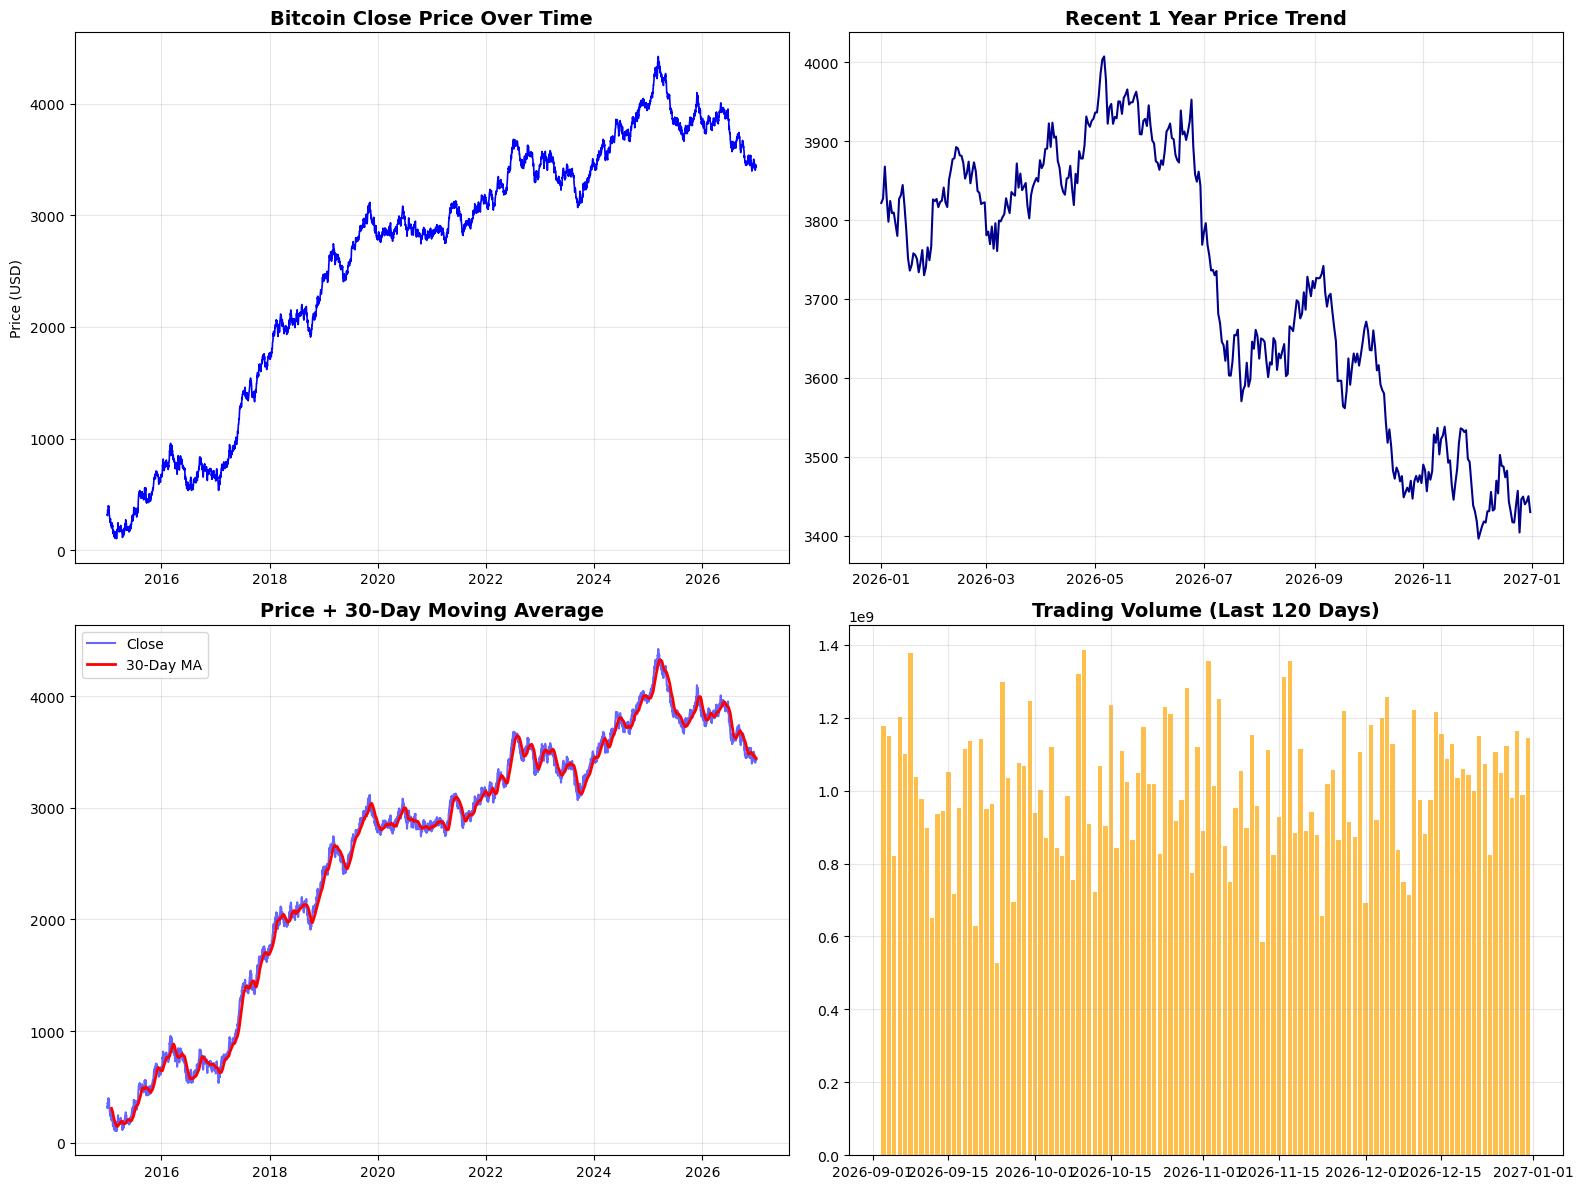

✅ Visualizations saved as 'btc_analysis.png'

 Project Completed Successfully!


In [6]:
import pandas as pd
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import os

# ====================== CONFIG ======================
EXCEL_PATH = r"C:\Users\ACER\OneDrive\Desktop\Final Project\DATASET\btc_price.xlsx"
DB_PATH = "btc_database.db"
# ===================================================

def load_data_to_sqlite():
    print("📂 Loading Bitcoin data from Excel...")
    df = pd.read_excel(EXCEL_PATH)
    print(f"✅ Loaded {len(df)} rows")
    
    df.columns = [col.strip() for col in df.columns]
    
    engine = create_engine(f'sqlite:///{DB_PATH}')
    df.to_sql('btc_price', engine, if_exists='replace', index=False)
    
    print(f"✅ Data saved to SQLite database: {DB_PATH}")
    return engine


def run_analysis(engine):
    print("\n🔍 Running SQL Analysis...\n")
    
    queries = {
        "1. Total Records": "SELECT COUNT(*) as total_records FROM btc_price;",
        
        "2. Date Range": """
            SELECT MIN(Date) as start_date, MAX(Date) as end_date 
            FROM btc_price;
        """,
        
        "3. Price Statistics": """
            SELECT 
                MIN(Close) as min_price,
                MAX(Close) as max_price,
                AVG(Close) as avg_price,
                AVG(Volume) as avg_volume
            FROM btc_price;
        """,
        
        "4. Yearly Performance": """
            SELECT 
                strftime('%Y', Date) as year,
                MIN(Close) as min_close,
                MAX(Close) as max_close,
                AVG(Close) as avg_close
            FROM btc_price
            GROUP BY year
            ORDER BY year DESC;
        """,
        
        "5. Top 10 Highest Prices": """
            SELECT Date, Close, Volume 
            FROM btc_price 
            ORDER BY Close DESC 
            LIMIT 10;
        """
    }
    
    with engine.connect() as conn:
        for title, query in queries.items():
            print(f"--- {title} ---")
            result = conn.execute(text(query))
            for row in result.fetchall():
                print(row)
            print("-" * 50)


def create_visualizations(engine):
    print("\n Generating Visualizations...")
    
    df = pd.read_sql("SELECT * FROM btc_price ORDER BY Date", engine)
    df['Date'] = pd.to_datetime(df['Date'])
    
    plt.style.use('default')
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Full Price Trend
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(df['Date'], df['Close'], color='blue', linewidth=1.2)
    ax1.set_title('Bitcoin Close Price Over Time', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (USD)')
    ax1.grid(True, alpha=0.3)
    
    # 2. Recent Trend (Last 365 days)
    recent = df.tail(365)
    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(recent['Date'], recent['Close'], color='darkblue')
    ax2.set_title('Recent 1 Year Price Trend', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. Moving Average
    ax3 = plt.subplot(2, 2, 3)
    df['MA30'] = df['Close'].rolling(window=30).mean()
    ax3.plot(df['Date'], df['Close'], color='blue', alpha=0.6, label='Close')
    ax3.plot(df['Date'], df['MA30'], color='red', linewidth=2, label='30-Day MA')
    ax3.set_title('Price + 30-Day Moving Average', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Volume
    ax4 = plt.subplot(2, 2, 4)
    ax4.bar(df['Date'].tail(120), df['Volume'].tail(120), color='orange', alpha=0.7)
    ax4.set_title('Trading Volume (Last 120 Days)', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('btc_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Visualizations saved as 'btc_analysis.png'")


# ====================== MAIN ======================
if __name__ == "__main__":
    print(" Bitcoin Price Analysis Project Started\n")
    
    engine = load_data_to_sqlite()
    run_analysis(engine)
    create_visualizations(engine)
    
    print("\n Project Completed Successfully!")